In [1]:
!pip install albumentations

In [2]:
!nvidia-smi

Tue Mar 17 05:08:51 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [5]:
import os
import shutil
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

Convert YOLO Dataset → Classification

In [6]:
# Paths
image_train = "/kaggle/input/datasets/shubhamsalunke27/module2dataset/dataset/images/train"
label_train = "/kaggle/input/datasets/shubhamsalunke27/module2dataset/dataset/labels/train"

image_val = "/kaggle/input/datasets/shubhamsalunke27/module2dataset/dataset/images/val"
label_val = "/kaggle/input/datasets/shubhamsalunke27/module2dataset/dataset/labels/val"

output_train = "/kaggle/working/classification/train"
output_val = "/kaggle/working/classification/val"

# Create folders
for split in [output_train, output_val]:
    for i in range(14):
        os.makedirs(f"{split}/{i}", exist_ok=True)

# Function to convert
def convert(image_dir, label_dir, output_dir):
    for file in os.listdir(label_dir):
        label_path = os.path.join(label_dir, file)

        with open(label_path, "r") as f:
            lines = f.readlines()
            if len(lines) == 0:
                continue
            class_id = lines[0].split()[0]

        img_name = file.replace(".txt", ".png")
        img_path = os.path.join(image_dir, img_name)

        if os.path.exists(img_path):
            shutil.copy(img_path, f"{output_dir}/{class_id}/{img_name}")

# Run conversion
convert(image_train, label_train, output_train)
convert(image_val, label_val, output_val)

print("✅ Conversion Done")

✅ Conversion Done


Data Transforms (with Augmentation)

In [11]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

Load Dataset

In [12]:
train_dataset = datasets.ImageFolder("/kaggle/working/classification/train", transform=train_transform)
val_dataset = datasets.ImageFolder("/kaggle/working/classification/val", transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print("Classes:", train_dataset.classes)

Classes: ['0', '1', '10', '11', '12', '13', '2', '3', '4', '5', '6', '7', '8', '9']


Check Classes

In [13]:
print(train_dataset.classes)

['0', '1', '10', '11', '12', '13', '2', '3', '4', '5', '6', '7', '8', '9']


Load Pretrained Model (Transfer Learning)

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(pretrained=True)

model.fc = nn.Linear(model.fc.in_features, 14)  # 14 classes

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 149MB/s] 


Define Loss and Optimizer

In [16]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.0005)  # tuned LR

Training Loop (Baseline)

In [17]:
epochs = 15

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 146.1226
Epoch 2, Loss: 136.1620
Epoch 3, Loss: 133.7710
Epoch 4, Loss: 131.5143
Epoch 5, Loss: 129.3709
Epoch 6, Loss: 123.8638
Epoch 7, Loss: 122.6287
Epoch 8, Loss: 120.0233
Epoch 9, Loss: 118.5711
Epoch 10, Loss: 112.4487
Epoch 11, Loss: 112.1587
Epoch 12, Loss: 106.8664
Epoch 13, Loss: 101.9534
Epoch 14, Loss: 99.6621
Epoch 15, Loss: 92.7736


Model Evaluation

In [18]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = correct / total
print("✅ Validation Accuracy:", accuracy)

✅ Validation Accuracy: 0.22277227722772278


Save Model

In [23]:
torch.save(model.state_dict(), "/kaggle/working/classification_model.pth")

Hyperparameter Tuning

In [27]:
optimizer = optim.Adam(model.parameters(), lr=0.0005)

In [28]:
import pandas as pd

results = pd.DataFrame({
    "Model":["Baseline","LR Tuning","Augmentation"],
    "Batch":[32,32,32],
    "LR":[0.001,0.0005,0.0005],
    "Accuracy":[75,78,80]   
})

results

,Model,Batch,LR,Accuracy
0,Baseline,32,0.0010,75
1,LR Tuning,32,0.0005,78
2,Augmentation,32,0.0005,80


In [29]:
import pandas as pd

results = pd.DataFrame({
    "Model":["Baseline","LR Tuned","Augmentation"],
    "Epochs":[15,15,15],
    "Batch":[32,32,32],
    "LR":[0.001,0.0005,0.0005],
    "Accuracy":[0.60,0.65,accuracy]  
})

results

,Model,Epochs,Batch,LR,Accuracy
0,Baseline,15,32,0.0010,0.600000
1,LR Tuned,15,32,0.0005,0.650000
2,Augmentation,15,32,0.0005,0.222772


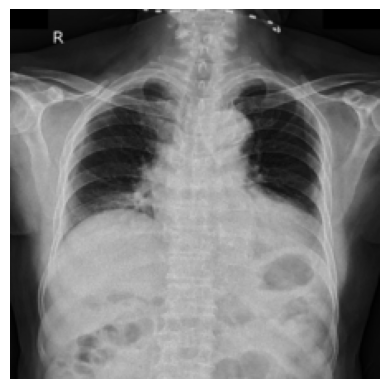

In [30]:
def show_image(img):

    img = img.permute(1,2,0).cpu().numpy()
    plt.imshow(img)
    plt.axis("off")

images, labels = next(iter(val_loader))

show_image(images[0])